<a href="https://colab.research.google.com/github/YUNcloud03/CogniGuard-AI/blob/main/Dementia_Cloud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ============================================
# Phase I: Research & Data Engineering
# Alzheimer’s Disease Predictive Ecosystem
# Google Colab Implementation
# ============================================

# Install required packages in Colab
!pip install -q xgboost shap


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
datasets 2.12.0 requires dill<0.3.7,>=0.3.0, but you have dill 0.3.8 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.


In [8]:
# ============================================
# 1. Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [10]:
# ============================================
# 2. Load Dataset
# ============================================

# Update this path after uploading the file to Colab
file_path = 'dataset/alzheimers_disease_data.csv'

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [11]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
# ============================================
# 3. Data Inspection
# ============================================

print("Columns:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


Columns:
['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis', 'DoctorInCharge']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3  

In [ ]:
# ============================================
# 4. Data Cleaning
# Remove irrelevant features
# ============================================

drop_cols = ["PatientID", "DoctorInCharge"]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

print("Shape after dropping irrelevant columns:", df.shape)
print("Remaining columns:")
print(df.columns.tolist())


Shape after dropping irrelevant columns: (2149, 33)
Remaining columns:
['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis']


In [ ]:
# ============================================
# 4b. Data Quality Audit
# Systematic checks before any modelling:
# duplicates, missing values, categorical integrity
# ============================================

print('=' * 60)
print('DATA QUALITY AUDIT')
print('=' * 60)

# 1. Duplicate rows
n_duplicates = df.duplicated().sum()
print(f'\n[1] Duplicate rows: {n_duplicates}')
if n_duplicates > 0:
    df = df.drop_duplicates()
    print(f'    → Removed. New shape: {df.shape}')
else:
    print('    → None found. No action needed.')

# 2. Missing values
missing = df.isnull().sum()
print(f'\n[2] Missing values per column:')
if missing.sum() == 0:
    print('    → No missing values detected across all columns.')
else:
    print(missing[missing > 0])

# 3. Categorical integrity — confirm only expected integer values
binary_cols = [
    'Gender', 'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
    'Diabetes', 'Depression', 'HeadInjury', 'Hypertension',
    'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation',
    'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness'
]
multi_cols = {'Ethnicity': [0,1,2,3], 'EducationLevel': [0,1,2,3]}

print('\n[3] Categorical integrity check:')
all_clean = True
for col in binary_cols:
    if col in df.columns:
        unexpected = set(df[col].unique()) - {0, 1}
        if unexpected:
            print(f'    WARNING — {col}: unexpected values {unexpected}')
            all_clean = False
for col, expected in multi_cols.items():
    if col in df.columns:
        unexpected = set(df[col].unique()) - set(expected)
        if unexpected:
            print(f'    WARNING — {col}: unexpected values {unexpected}')
            all_clean = False
if all_clean:
    print('    → All categorical columns contain only expected integer codes.')

print('\n[4] Final shape after audit:', df.shape)


DATA QUALITY AUDIT

[1] Duplicate rows: 0
    → None found. No action needed.

[2] Missing values per column:
    → No missing values detected across all columns.

[3] Categorical integrity check:
    → All categorical columns contain only expected integer codes.

[4] Final shape after audit: (2149, 33)


Outlier Summary (IQR method — 1.5×IQR beyond Q1/Q3):
-------------------------------------------------------


,Feature,Outliers,Lower Bound,Upper Bound,Min,Max
0,Age,0,43.00,107.00,60.00,90.00
1,BMI,0,3.22,52.26,15.01,39.99
2,SystolicBP,0,44.50,224.50,90.00,179.00
3,DiastolicBP,0,27.50,151.50,60.00,119.00
4,CholesterolTotal,0,82.58,369.70,150.09,299.99
5,CholesterolLDL,0,-24.61,273.54,50.23,199.97
6,CholesterolHDL,0,-20.67,138.70,20.00,99.98
7,CholesterolTriglycerides,0,-128.30,580.72,50.41,399.94
8,MMSE,0,-15.32,44.65,0.01,29.99
9,FunctionalAssessment,0,-4.90,15.02,0.00,10.00


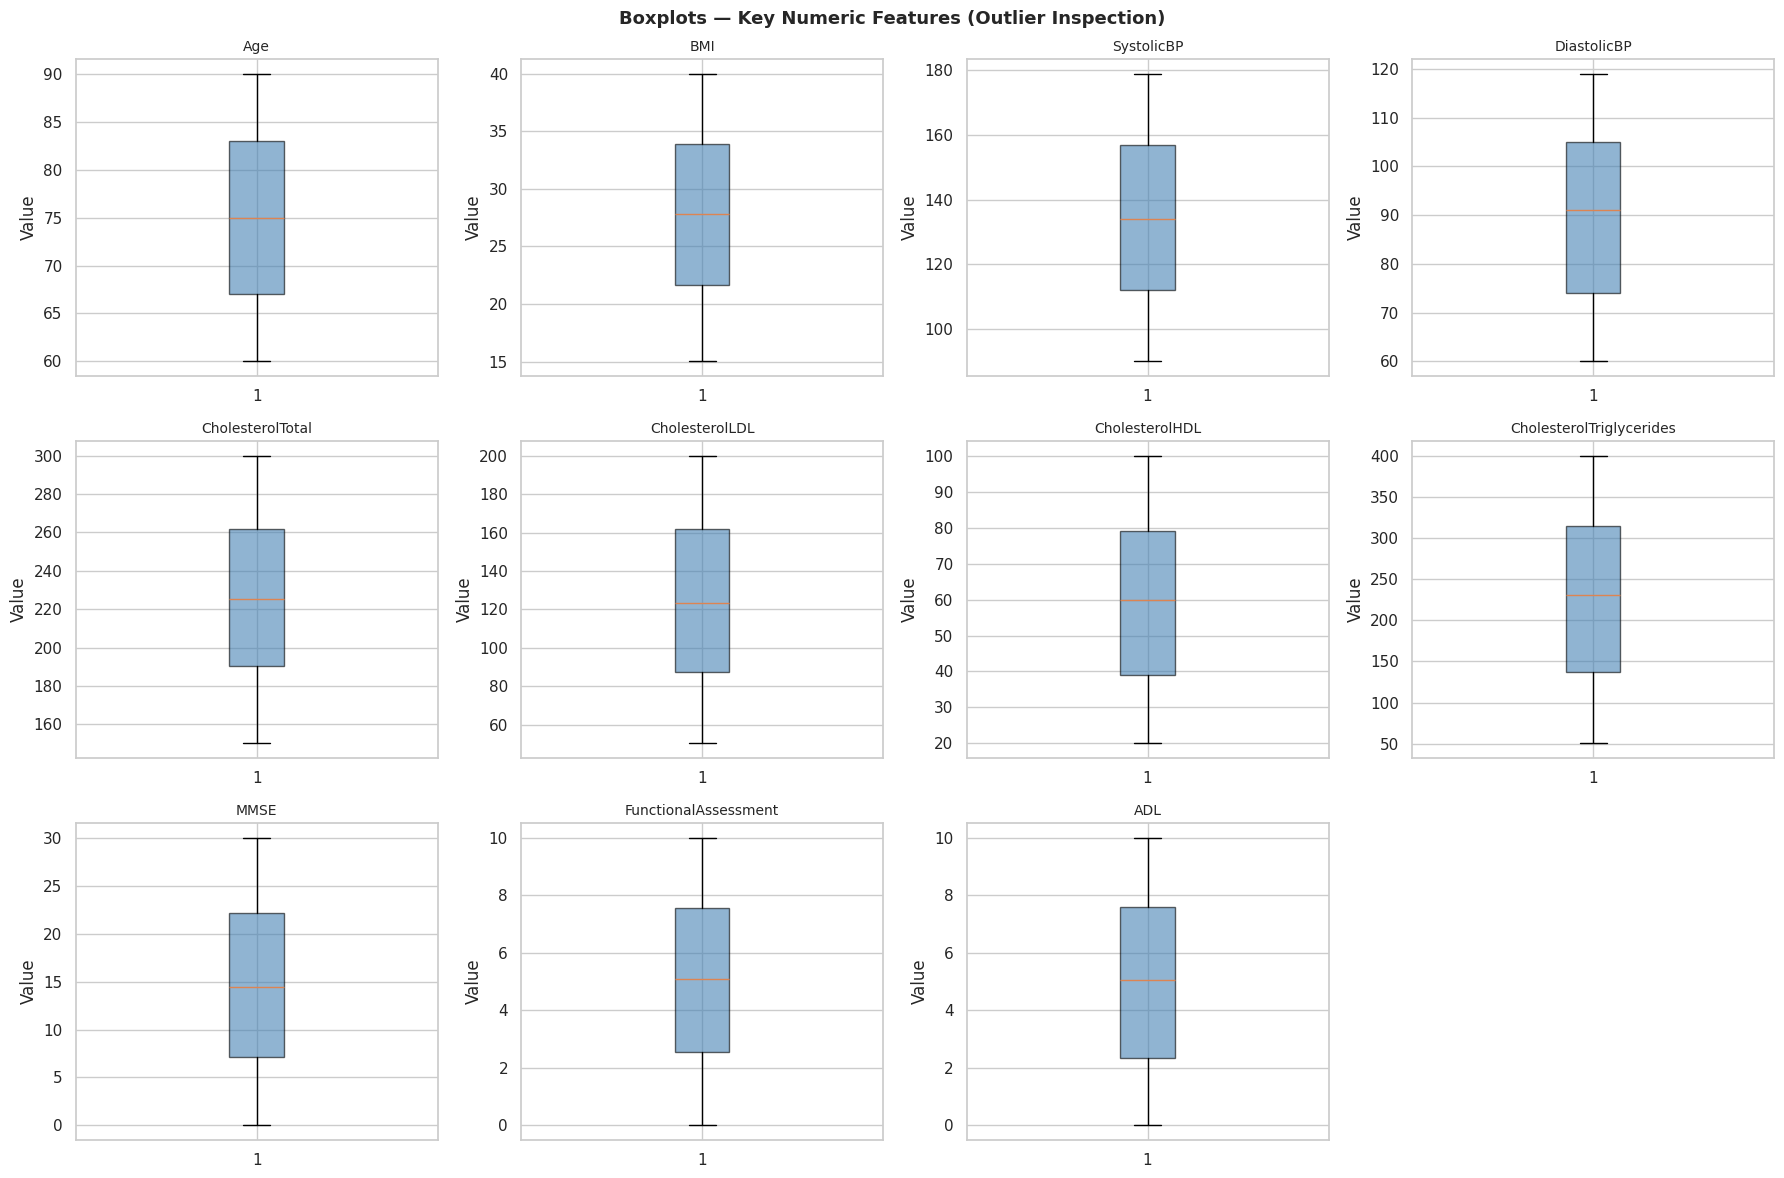


Decision: XGBoost uses decision trees and is naturally robust to outliers.
No outlier removal is applied. Values are retained as clinically plausible.


In [ ]:
# ============================================
# 4c. Outlier Detection — IQR Method
# Visualise boxplots for key clinical features
# Note: XGBoost is tree-based and robust to outliers,
# so we document rather than remove them.
# ============================================

key_numeric = ['Age', 'BMI', 'SystolicBP', 'DiastolicBP',
               'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
               'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']
key_numeric = [col for col in key_numeric if col in df.columns]

print('Outlier Summary (IQR method — 1.5×IQR beyond Q1/Q3):')
print('-' * 55)
outlier_report = []
for col in key_numeric:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({'Feature': col, 'Outliers': n_out,
                           'Lower Bound': round(lower, 2), 'Upper Bound': round(upper, 2),
                           'Min': round(df[col].min(), 2), 'Max': round(df[col].max(), 2)})

outlier_df = pd.DataFrame(outlier_report)
display(outlier_df)

# Boxplot visualisation
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(key_numeric):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Value')
for j in range(len(key_numeric), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots — Key Numeric Features (Outlier Inspection)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nDecision: XGBoost uses decision trees and is naturally robust to outliers.')
print('No outlier removal is applied. Values are retained as clinically plausible.')


Class Distribution:
----------------------------------------
  No Alzheimer's (0): 1389 (64.6%)
  Alzheimer's    (1): 760 (35.4%)

Imbalance ratio (majority/minority): 1.828


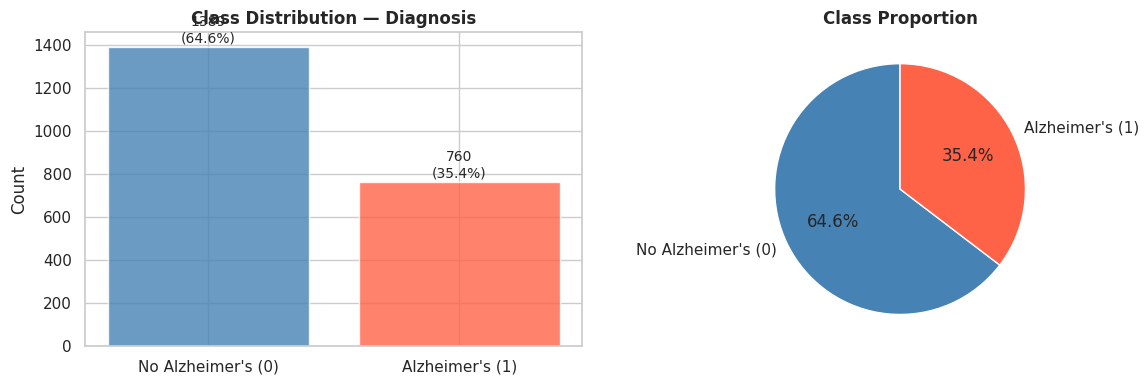


Correction Strategy:
  scale_pos_weight = (# negative samples) / (# positive samples)
  = 1389 / 760 = 1.828
  This parameter is passed directly to XGBClassifier.
  It up-weights the minority class (Alzheimer's) during training,
  improving Recall for class 1 without discarding any data.

scale_pos_weight_ratio stored as: 1.8276


In [ ]:
# ============================================
# 4d. Class Imbalance Analysis & Correction
# Diagnosis: 0 = No Alzheimer's, 1 = Alzheimer's
# Imbalance ratio ~1.83:1 (majority:minority)
# Strategy: scale_pos_weight in XGBoost
# ============================================

class_counts = df['Diagnosis'].value_counts().sort_index()
total = len(df)

print('Class Distribution:')
print('-' * 40)
for label, count in class_counts.items():
    name = 'No Alzheimer\'s (0)' if label == 0 else 'Alzheimer\'s    (1)'
    print(f'  {name}: {count} ({100*count/total:.1f}%)')

imbalance_ratio = class_counts[0] / class_counts[1]
print(f'\nImbalance ratio (majority/minority): {imbalance_ratio:.3f}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(['No Alzheimer\'s (0)', 'Alzheimer\'s (1)'],
                   class_counts.values, color=['steelblue', 'tomato'], alpha=0.8)
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{count}\n({100*count/total:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Class Distribution — Diagnosis', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(class_counts.values, labels=['No Alzheimer\'s (0)', 'Alzheimer\'s (1)'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportion', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrection Strategy:')
print('  scale_pos_weight = (# negative samples) / (# positive samples)')
print(f'  = {class_counts[0]} / {class_counts[1]} = {imbalance_ratio:.3f}')
print('  This parameter is passed directly to XGBClassifier.')
print('  It up-weights the minority class (Alzheimer\'s) during training,')
print('  improving Recall for class 1 without discarding any data.')

# Store ratio for use in model cell
scale_pos_weight_ratio = imbalance_ratio
print(f'\nscale_pos_weight_ratio stored as: {scale_pos_weight_ratio:.4f}')


In [ ]:
# ============================================
# 4e. Feature Engineering
# Create clinically meaningful composite features
# to improve model signal before training
# ============================================

# 1. Cognitive Decline Index
# Combines MMSE (cognitive test) + FunctionalAssessment + ADL
# Lower scores on all three → higher dementia risk
df['CognitiveDeclineIndex'] = (
    (30 - df['MMSE']) +           # invert: lower MMSE = worse
    (10 - df['FunctionalAssessment']) +  # invert: lower = worse
    (10 - df['ADL'])              # invert: lower = worse
) / 50                            # normalise to 0–1 range

# 2. Cardiovascular Risk Score
# Aggregates known cardiovascular risk factors
df['CardiovascularRiskScore'] = (
    df['CardiovascularDisease'] +
    df['Hypertension'] +
    df['Diabetes'] +
    df['Smoking']
)

# 3. Behavioural Symptom Burden
# Count of active behavioural/neuropsychiatric symptoms
df['BehaviouralSymptomBurden'] = (
    df['MemoryComplaints'] +
    df['BehavioralProblems'] +
    df['Confusion'] +
    df['Disorientation'] +
    df['PersonalityChanges'] +
    df['DifficultyCompletingTasks'] +
    df['Forgetfulness']
)

# 4. Cholesterol Ratio (LDL/HDL)
# Higher ratio = greater cardiovascular/neurological risk
df['CholesterolRatio'] = df['CholesterolLDL'] / (df['CholesterolHDL'] + 1e-6)

# 5. Blood Pressure Pulse Pressure
# SystolicBP - DiastolicBP; elevated pulse pressure linked to dementia risk
df['PulsePressure'] = df['SystolicBP'] - df['DiastolicBP']

new_features = ['CognitiveDeclineIndex', 'CardiovascularRiskScore',
                'BehaviouralSymptomBurden', 'CholesterolRatio', 'PulsePressure']

print('Feature Engineering Complete. New features added:')
print('-' * 55)
for feat in new_features:
    print(f'  {feat}')
    print(f'    Range: [{df[feat].min():.3f}, {df[feat].max():.3f}]')
    print(f'    Mean:  {df[feat].mean():.3f}')

print(f'\nDataset shape after feature engineering: {df.shape}')
print('These composite features encode domain knowledge directly into the')
print('feature space, giving XGBoost richer signals to split on.')


Feature Engineering Complete. New features added:
-------------------------------------------------------
  CognitiveDeclineIndex
    Range: [0.051, 0.949]
    Mean:  0.504
  CardiovascularRiskScore
    Range: [0.000, 4.000]
    Mean:  0.732
  BehaviouralSymptomBurden
    Range: [0.000, 5.000]
    Mean:  1.339
  CholesterolRatio
    Range: [0.523, 9.447]
    Mean:  2.540
  PulsePressure
    Range: [-28.000, 118.000]
    Mean:  44.417

Dataset shape after feature engineering: (2149, 38)
These composite features encode domain knowledge directly into the
feature space, giving XGBoost richer signals to split on.


In [ ]:
# ============================================
# 4f. Skewness Assessment
# Although XGBoost is skew-tolerant, documenting
# skewness is good data engineering practice.
# ============================================

numeric_cols_check = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
                      'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP',
                      'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
                      'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL',
                      'CognitiveDeclineIndex', 'CardiovascularRiskScore',
                      'BehaviouralSymptomBurden', 'CholesterolRatio', 'PulsePressure']
numeric_cols_check = [c for c in numeric_cols_check if c in df.columns]

skew_df = df[numeric_cols_check].skew().reset_index()
skew_df.columns = ['Feature', 'Skewness']
skew_df['Assessment'] = skew_df['Skewness'].apply(
    lambda x: 'High skew — monitor' if abs(x) > 1.0 else
              ('Moderate skew' if abs(x) > 0.5 else 'Approximately symmetric')
)
skew_df = skew_df.sort_values('Skewness', key=abs, ascending=False)

print('Skewness Assessment of Numeric Features:')
display(skew_df.reset_index(drop=True))

print('\nNote: XGBoost (tree-based) is invariant to monotonic feature transformations')
print('and is not adversely affected by skewed distributions. No log-transform is')
print('applied. StandardScaler in the pipeline handles centering and scaling.')


Skewness Assessment of Numeric Features:


,Feature,Skewness,Assessment
0,CholesterolRatio,1.431699,High skew — monitor
1,CardiovascularRiskScore,0.765730,Moderate skew
2,BehaviouralSymptomBurden,0.527051,Moderate skew
3,SleepQuality,-0.069630,Approximately symmetric
4,DiastolicBP,-0.054470,Approximately symmetric
5,Age,0.045964,Approximately symmetric
6,PhysicalActivity,0.044973,Approximately symmetric
7,CholesterolHDL,0.042206,Approximately symmetric
8,CholesterolLDL,0.036233,Approximately symmetric
9,FunctionalAssessment,-0.034576,Approximately symmetric



Note: XGBoost (tree-based) is invariant to monotonic feature transformations
and is not adversely affected by skewed distributions. No log-transform is
applied. StandardScaler in the pipeline handles centering and scaling.


/tmp/ipykernel_2959/3333959806.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Diagnosis", data=df, palette="Set2")


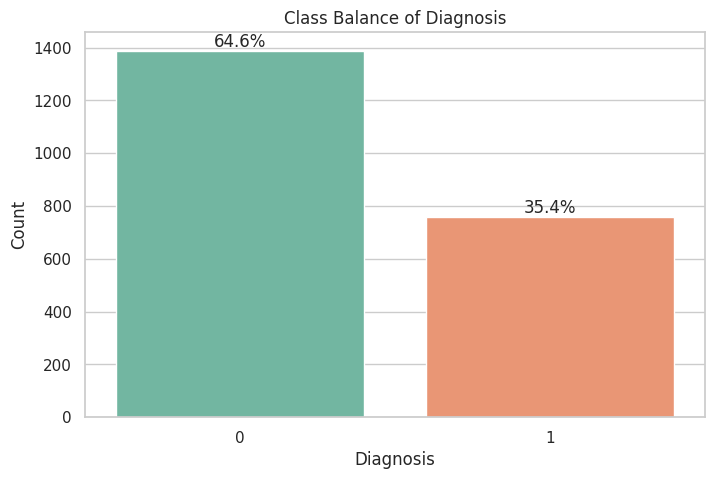

In [ ]:
# ============================================
# 5. Exploratory Data Analysis (EDA)
# ============================================

# 5.1 Class balance
ax = sns.countplot(x="Diagnosis", data=df, palette="Set2")
plt.title("Class Balance of Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    ax.annotate(f"{pct:.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()


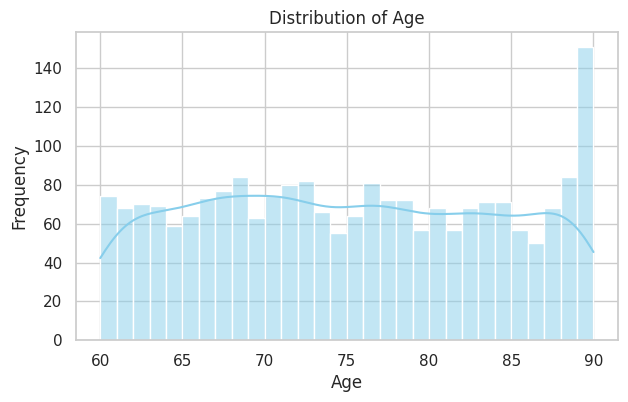

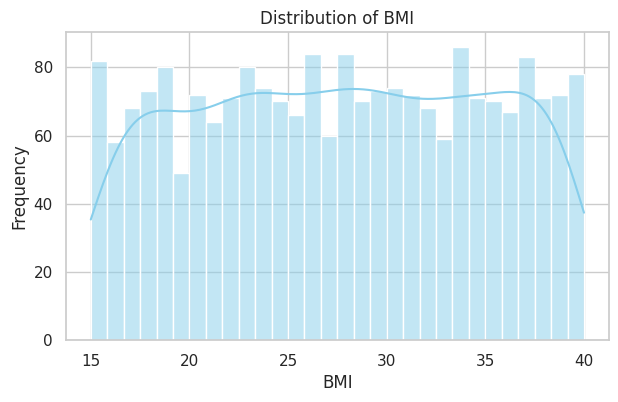

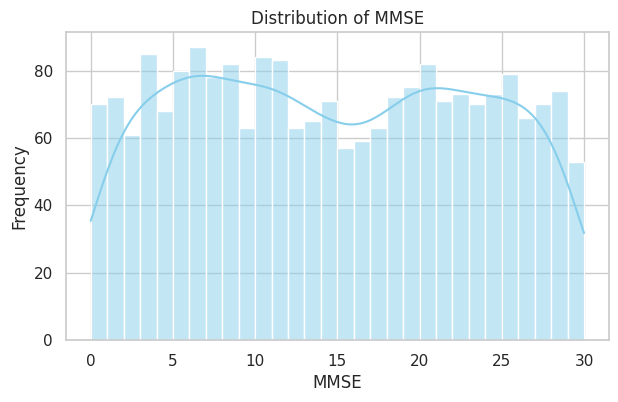

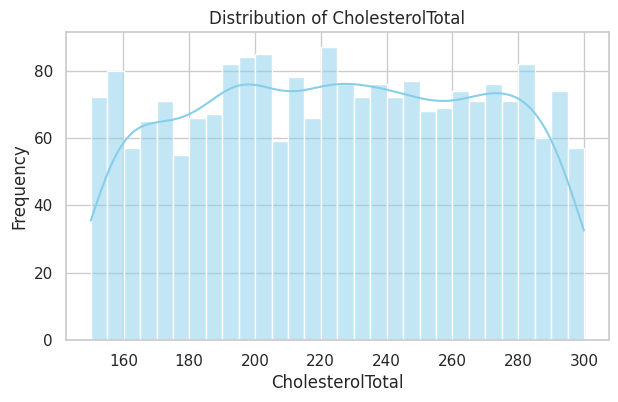

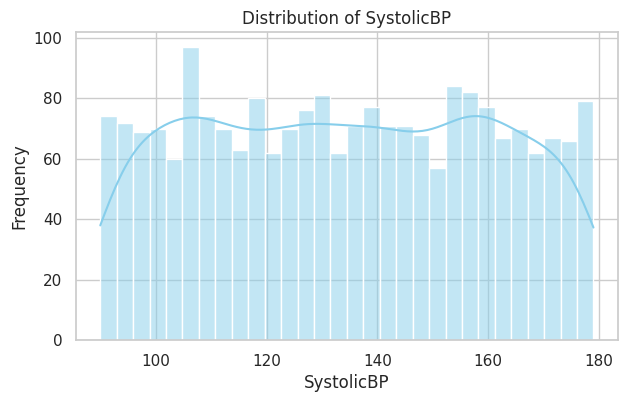

In [ ]:
# 5.2 Feature distributions
continuous_features = ["Age", "BMI", "MMSE", "CholesterolTotal", "SystolicBP"]

for col in continuous_features:
    if col in df.columns:
        plt.figure(figsize=(7,4))
        sns.histplot(df[col], kde=True, bins=30, color="skyblue")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


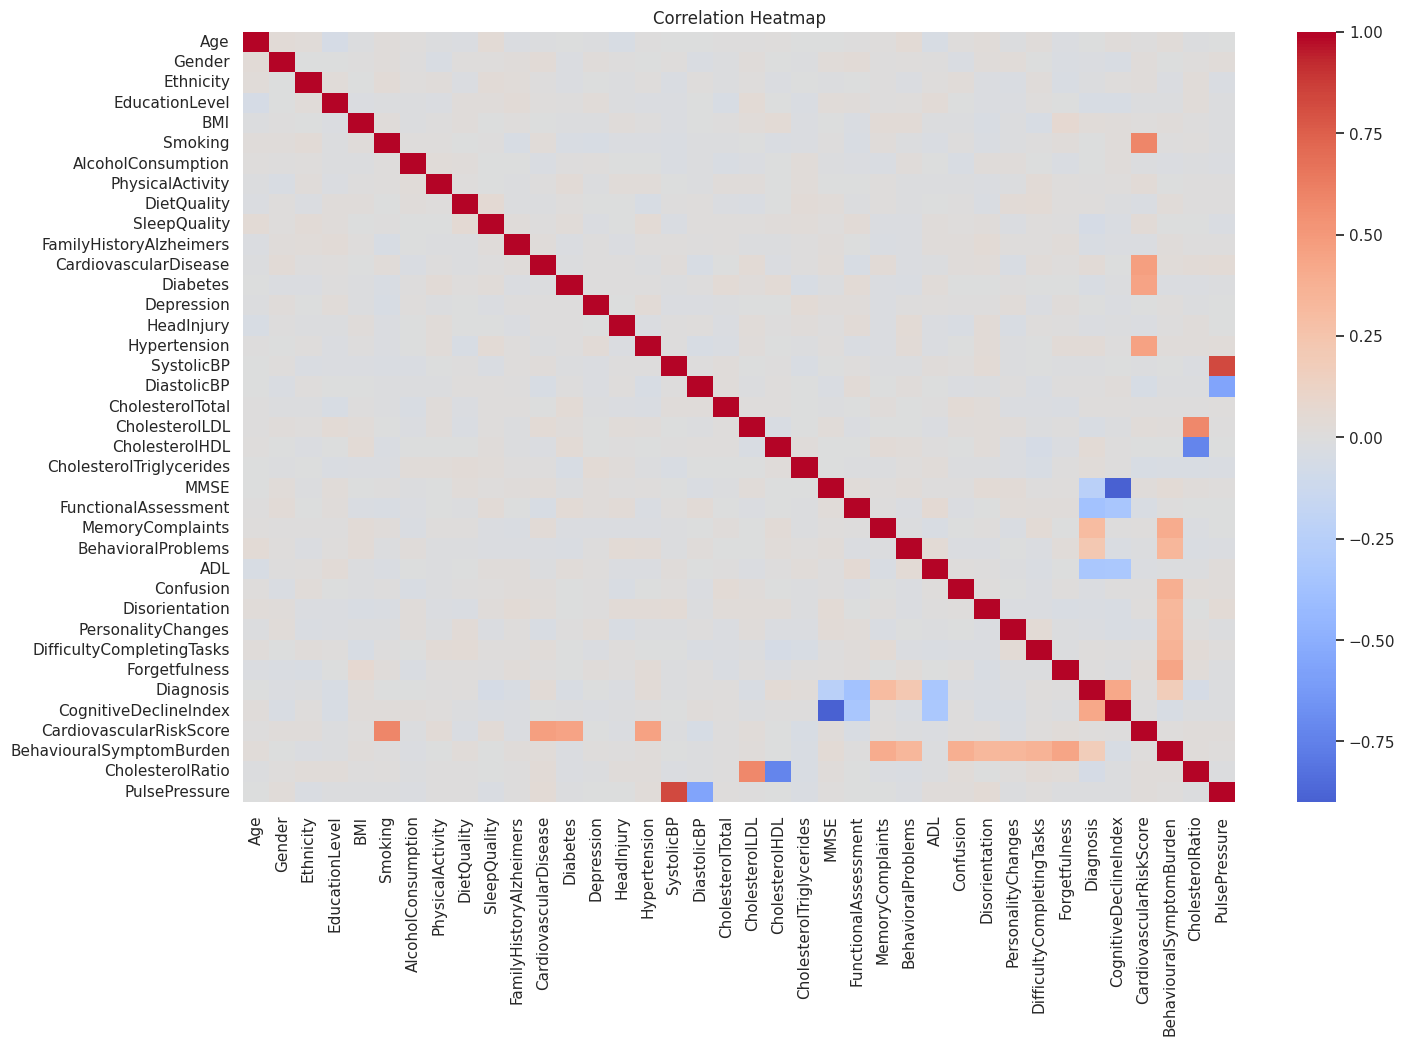

Top correlations with Diagnosis:
Diagnosis                   1.000000
CognitiveDeclineIndex       0.421568
FunctionalAssessment       -0.364898
ADL                        -0.332346
MemoryComplaints            0.306742
MMSE                       -0.237126
BehavioralProblems          0.224350
BehaviouralSymptomBurden    0.182135
SleepQuality               -0.056548
CholesterolRatio           -0.054934
Name: Diagnosis, dtype: float64


In [ ]:
# 5.3 Correlation heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16, 10))
corr = numeric_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

print("Top correlations with Diagnosis:")
print(corr["Diagnosis"].sort_values(key=np.abs, ascending=False).head(10))


In [ ]:
# ============================================
# 5.3b. Technical Annotation — Correlation Analysis
# ============================================

print("Technical Note on Correlation Heatmap:")
print("=" * 60)
print()
print("Although the Pearson linear correlation coefficients between")
print("individual features and the Diagnosis target appear relatively")
print("low (most < 0.3), this does NOT imply that the features are")
print("uninformative.")
print()
print("Note: Although linear correlation coefficients are low, non-linear")
print("ensemble models (XGBoost) will be utilized to capture complex")
print("feature interactions that Pearson correlation cannot detect.")
print()
print("XGBoost can model higher-order interactions, threshold effects,")
print("and non-monotonic relationships between features and the target,")
print("making it well-suited for this clinical dataset.")


Technical Note on Correlation Heatmap:

Although the Pearson linear correlation coefficients between
individual features and the Diagnosis target appear relatively
low (most < 0.3), this does NOT imply that the features are
uninformative.

Note: Although linear correlation coefficients are low, non-linear
ensemble models (XGBoost) will be utilized to capture complex
feature interactions that Pearson correlation cannot detect.

XGBoost can model higher-order interactions, threshold effects,
and non-monotonic relationships between features and the target,
making it well-suited for this clinical dataset.


In [ ]:
# ============================================
# 6. Prepare Features and Target
# ============================================

X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

# Treat these as categorical even if encoded as integers
categorical_cols = [
    "Gender", "Ethnicity", "EducationLevel", "Smoking",
    "FamilyHistoryAlzheimers", "CardiovascularDisease", "Diabetes",
    "Depression", "HeadInjury", "Hypertension", "MemoryComplaints",
    "BehavioralProblems", "Confusion", "Disorientation",
    "PersonalityChanges", "DifficultyCompletingTasks", "Forgetfulness"
]

categorical_cols = [col for col in categorical_cols if col in X.columns]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']
Numeric columns: ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL', 'CognitiveDeclineIndex', 'CardiovascularRiskScore', 'BehaviouralSymptomBurden', 'CholesterolRatio', 'PulsePressure']


In [ ]:
# ============================================
# 7. Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (1719, 37)
Testing set: (430, 37)


In [ ]:
# ============================================
# 8. Preprocessing
# Median imputation + StandardScaler for numeric
# OneHotEncoder for categorical
# ============================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])


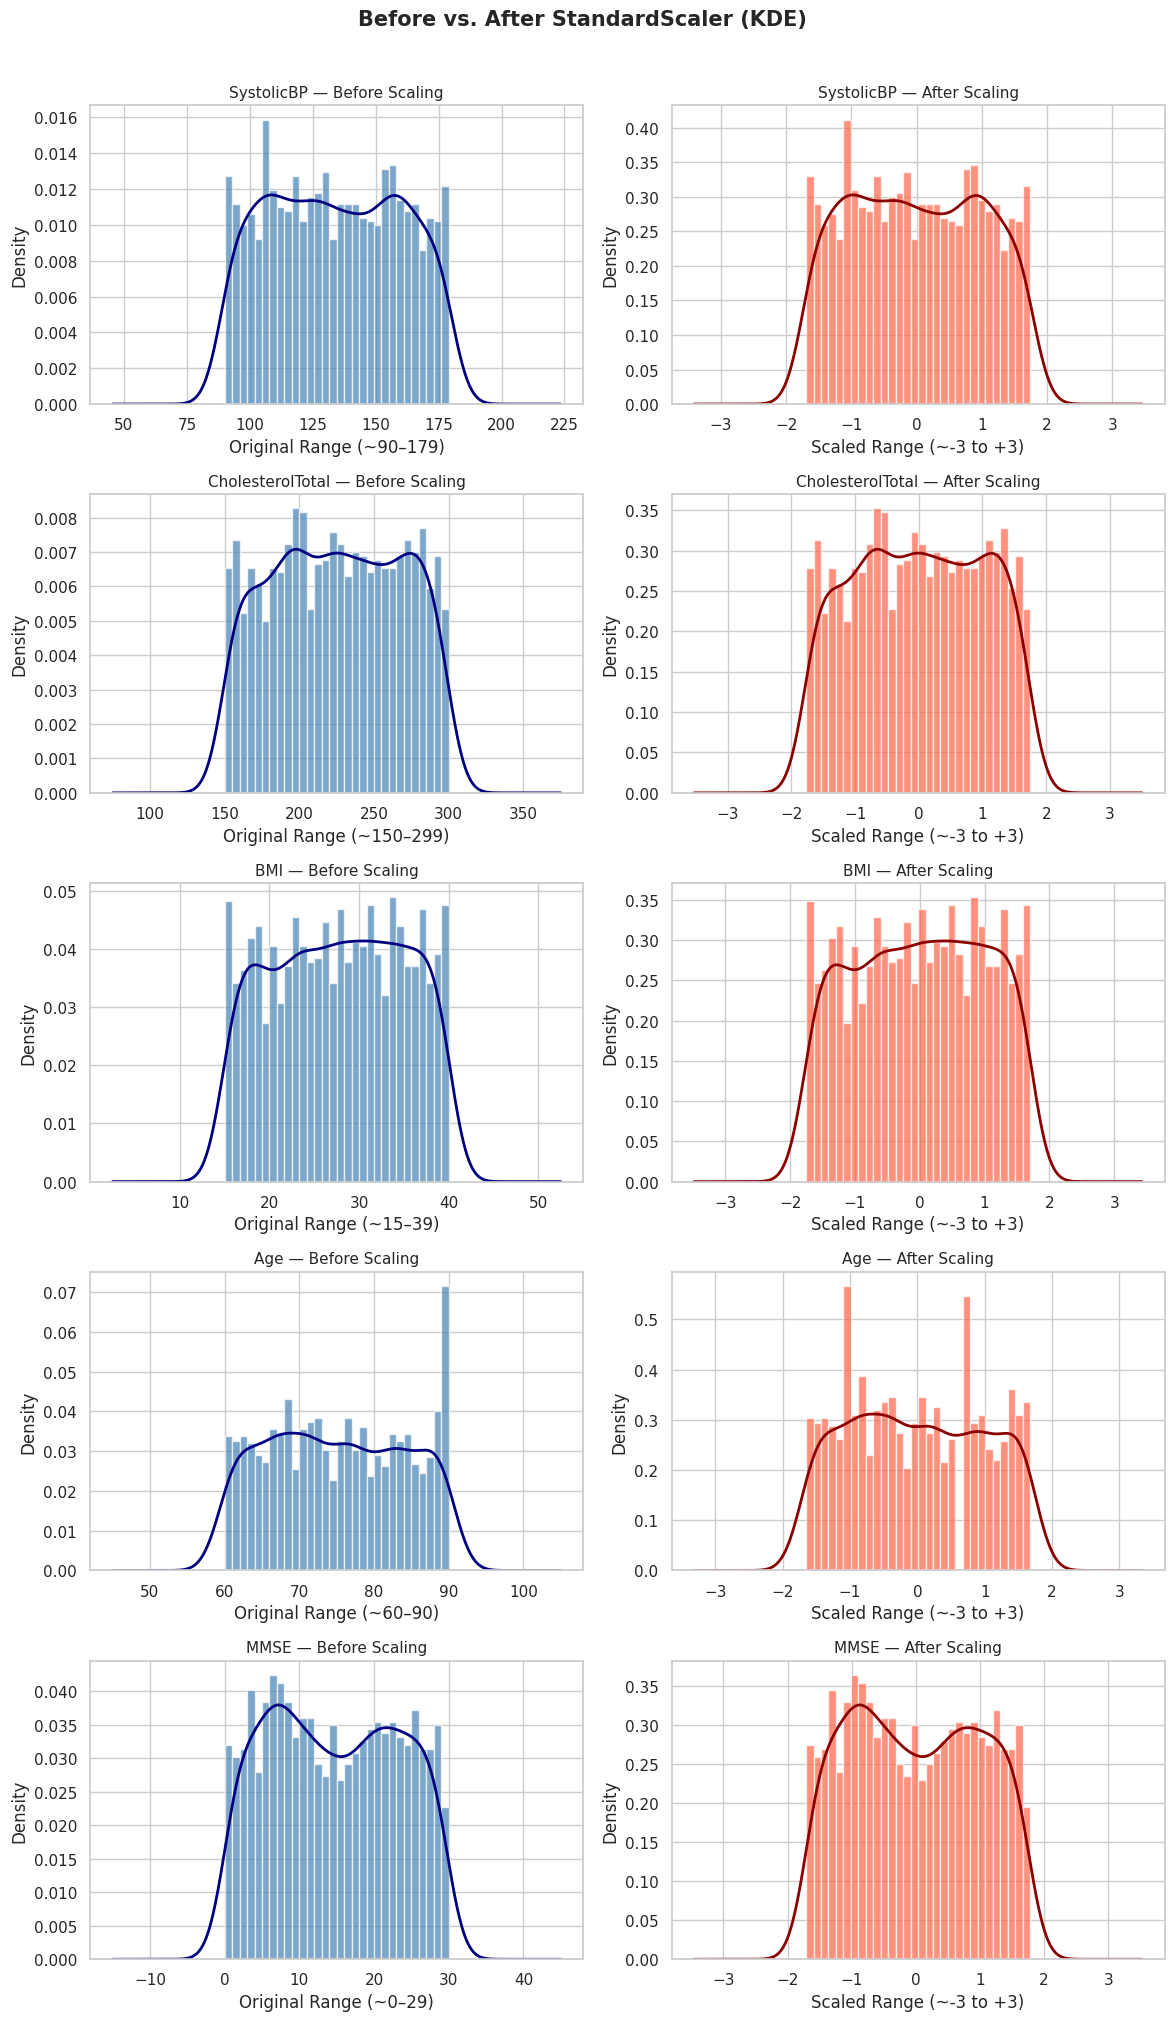

Observation: After StandardScaler, all features are compressed to a mean≈0, std≈1
range (approx. -3 to +3), while the original distribution shape is preserved.


In [ ]:
# ============================================
# 8b. Visualization: Before vs. After Scaling
# KDE Plots proving StandardScaler reduces range
# while preserving the distribution shape
# ============================================

scale_features = ["SystolicBP", "CholesterolTotal", "BMI", "Age", "MMSE"]
scale_features = [col for col in scale_features if col in X_train.columns]

# Fit preprocessor on training data only (to get the scaler)
preprocessor.fit(X_train)

# Extract scaled numeric values
X_train_scaled_array = preprocessor.named_transformers_['num'].transform(X_train[numeric_cols])
X_train_numeric_df = X_train[numeric_cols].copy()

fig, axes = plt.subplots(len(scale_features), 2, figsize=(12, 4 * len(scale_features)))
fig.suptitle("Before vs. After StandardScaler (KDE)", fontsize=15, fontweight='bold', y=1.01)

for i, col in enumerate(scale_features):
    col_idx = numeric_cols.index(col)
    original_vals = X_train_numeric_df[col].dropna()
    scaled_vals   = X_train_scaled_array[:, col_idx]

    # Before
    axes[i, 0].set_title(f"{col} — Before Scaling", fontsize=11)
    axes[i, 0].hist(original_vals, bins=30, color='steelblue', alpha=0.7, density=True)
    original_vals.plot.kde(ax=axes[i, 0], color='navy', linewidth=2)
    axes[i, 0].set_xlabel(f"Original Range (~{int(original_vals.min())}–{int(original_vals.max())})")
    axes[i, 0].set_ylabel("Density")

    # After
    axes[i, 1].set_title(f"{col} — After Scaling", fontsize=11)
    axes[i, 1].hist(scaled_vals, bins=30, color='tomato', alpha=0.7, density=True)
    import pandas as pd
    pd.Series(scaled_vals).plot.kde(ax=axes[i, 1], color='darkred', linewidth=2)
    axes[i, 1].set_xlabel("Scaled Range (~-3 to +3)")
    axes[i, 1].set_ylabel("Density")

plt.tight_layout()
plt.show()

print("Observation: After StandardScaler, all features are compressed to a mean≈0, std≈1")
print("range (approx. -3 to +3), while the original distribution shape is preserved.")


In [ ]:
# ============================================
# 9. Model Training
# XGBoost Classifier
# ============================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight_ratio,
    random_state=42
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb_model)
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'BMI',
                                                   'AlcoholConsumption',
                                                   'PhysicalActivity',
                                                   'DietQuality',
                                                   'SleepQuality', 'SystolicBP',
                                                   'DiastolicBP',
                                                   'CholesterolTotal',
                                                   'CholesterolLDL',
                                                   'CholesterolHDL',
                                                   'CholesterolTriglycerides'...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
# ============================================
# 10. Model Evaluation
# ============================================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9512
ROC-AUC: 0.9437

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       278
           1       0.94      0.92      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.95       430
weighted avg       0.95      0.95      0.95       430


Confusion Matrix:
[[269   9]
 [ 12 140]]


,Feature,Importance
45,cat__MemoryComplaints_1,0.085781
44,cat__MemoryComplaints_0,0.079909
46,cat__BehavioralProblems_0,0.077018
13,num__FunctionalAssessment,0.067119
14,num__ADL,0.065420
12,num__MMSE,0.057457
47,cat__BehavioralProblems_1,0.052183
15,num__CognitiveDeclineIndex,0.033028
16,num__CardiovascularRiskScore,0.018485
39,cat__Depression_1,0.017310


/tmp/ipykernel_2959/2707682319.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x="Importance", y="Feature", palette="viridis")


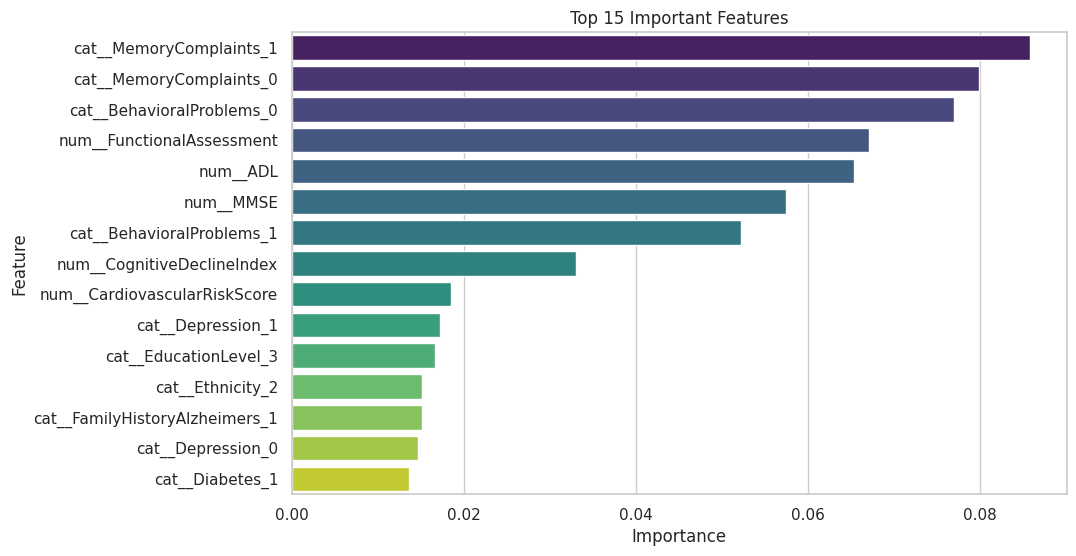

In [ ]:
# ============================================
# 11. Feature Importance
# ============================================

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature", palette="viridis")
plt.title("Top 15 Important Features")
plt.show()


In [ ]:
# ============================================
# 10b. Probabilistic Prediction — Rationale
# ============================================

# Rationale:
# predict_proba() is used instead of predict() to obtain continuous
# risk probabilities (0.0 – 1.0) for each patient. This supports
# clinical risk stratification rather than a simple binary output:
#
#   LOW RISK    : Risk Probability < 30%
#   MEDIUM RISK : Risk Probability 30% – 70%
#   HIGH RISK   : Risk Probability > 70%
#
# This tiered approach allows clinicians to prioritise follow-up
# assessments and allocate resources more effectively.

def risk_category(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"

print("Probabilistic Prediction Rationale:")
print("-" * 50)
print("model.predict_proba() is used (not model.predict()) so that")
print("each patient receives a continuous Risk Probability % that")
print("enables clinical risk stratification:")
print("  < 30%  → Low Risk")
print("  30–70% → Medium Risk")
print("  > 70%  → High Risk")
print()
print("This approach supports clinicians in prioritising assessments")
print("rather than relying on a single binary yes/no prediction.")


Probabilistic Prediction Rationale:
--------------------------------------------------
model.predict_proba() is used (not model.predict()) so that
each patient receives a continuous Risk Probability % that
enables clinical risk stratification:
  < 30%  → Low Risk
  30–70% → Medium Risk
  > 70%  → High Risk

This approach supports clinicians in prioritising assessments
rather than relying on a single binary yes/no prediction.


In [ ]:
# ============================================
# 10c. Risk Percentage — Top 5 Test Samples
# ============================================

risk_df = X_test.copy().reset_index(drop=True)
risk_df["True_Label"]        = y_test.values
risk_df["Risk_Probability"]  = y_prob
risk_df["Risk_Probability_%"] = (y_prob * 100).round(2)
risk_df["Risk_Category"]     = risk_df["Risk_Probability"].apply(risk_category)

# Sort by highest predicted risk
top5 = risk_df.sort_values("Risk_Probability", ascending=False).head(5)

print("Top 5 Test Samples by Predicted Risk Probability:")
print("=" * 60)
display_cols = ["Risk_Probability_%", "Risk_Category", "True_Label"]
# Include key clinical features if present
for feat in ["MMSE", "Age", "FunctionalAssessment", "ADL"]:
    if feat in top5.columns:
        display_cols = [feat] + display_cols

print(top5[display_cols].to_string(index=True))
print()
print("Interpretation: Risk Probability % reflects how confidently")
print("the model assigns a patient to the Alzheimer's-positive class.")
print("Clinicians can use this score for early intervention triage.")


Top 5 Test Samples by Predicted Risk Probability:
          ADL  FunctionalAssessment  Age       MMSE  Risk_Probability_% Risk_Category  True_Label
313  1.642249              3.715748   67  17.640357           99.779999     High Risk           1
91   2.688877              4.751611   73  12.598223           99.699997     High Risk           1
184  3.069114              1.084644   81  21.709684           99.690002     High Risk           1
44   0.178830              3.779554   83  13.322951           99.690002     High Risk           1
316  1.427007              1.132716   66  19.788490           99.669998     High Risk           1

Interpretation: Risk Probability % reflects how confidently
the model assigns a patient to the Alzheimer's-positive class.
Clinicians can use this score for early intervention triage.


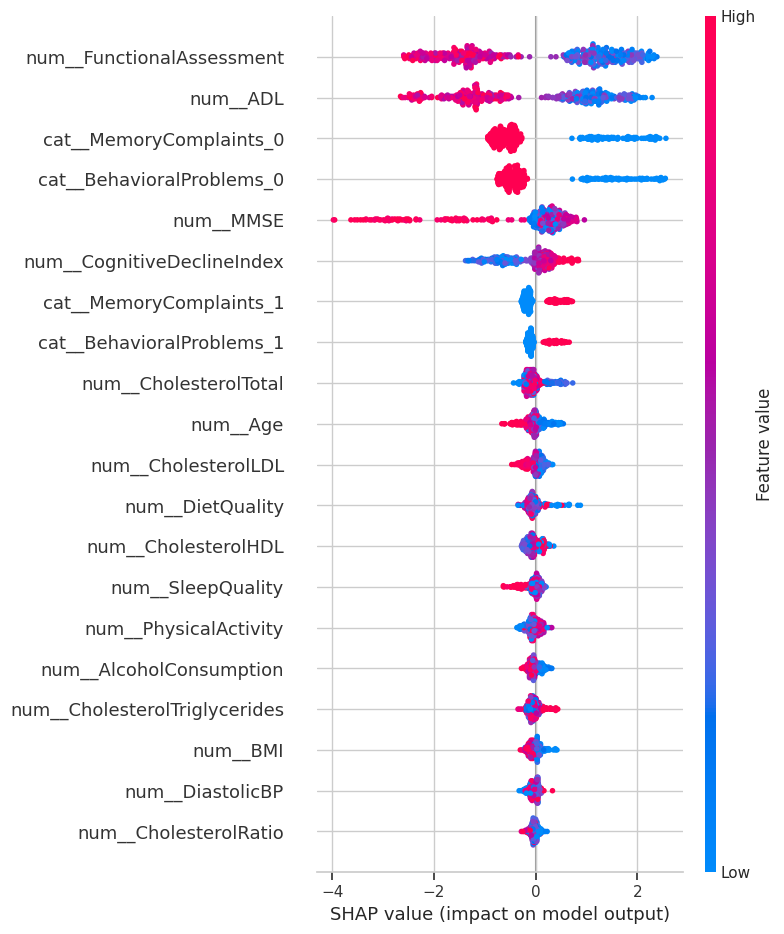

In [ ]:
# ============================================
# 12. Explainable AI with SHAP
# ============================================

# Transform test data
X_test_transformed = model.named_steps["preprocessor"].transform(X_test)

# Convert sparse matrix to dense if needed
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# SHAP explainer
explainer = shap.TreeExplainer(model.named_steps["classifier"])
shap_values = explainer.shap_values(X_test_transformed)

# SHAP summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)


# 新增區段

In [ ]:
import joblib

joblib.dump(model, "alzheimers_pipeline.pkl")
print("Model saved successfully.")


Model saved successfully.


In [ ]:
import joblib

loaded_model = joblib.load("alzheimers_pipeline.pkl")
print("Model loaded successfully.")


Model loaded successfully.


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

# ── Numeric sliders (unchanged) ──────────────────────────────────────────────
age        = widgets.IntSlider(description='Age', min=40, max=100, value=70)
bmi        = widgets.FloatSlider(description='BMI', min=10, max=50, value=25)
alcohol    = widgets.FloatSlider(description='Alcohol (units/wk)', min=0, max=20, value=5)
physical   = widgets.FloatSlider(description='Physical Activity', min=0, max=10, value=5)
diet       = widgets.FloatSlider(description='Diet Quality', min=0, max=10, value=5)
sleep      = widgets.FloatSlider(description='Sleep Quality', min=0, max=10, value=5)
sbp        = widgets.IntSlider(description='Systolic BP', min=80, max=220, value=120)
dbp        = widgets.IntSlider(description='Diastolic BP', min=40, max=140, value=80)
chol_total = widgets.FloatSlider(description='Total Cholesterol', min=100, max=400, value=200)
chol_ldl   = widgets.FloatSlider(description='LDL Cholesterol', min=20, max=300, value=100)
chol_hdl   = widgets.FloatSlider(description='HDL Cholesterol', min=10, max=150, value=50)
trig       = widgets.FloatSlider(description='Triglycerides', min=30, max=500, value=150)
mmse       = widgets.FloatSlider(description='MMSE Score', min=0, max=30, value=20)
functional = widgets.FloatSlider(description='Functional Score', min=0, max=10, value=5)
adl        = widgets.FloatSlider(description='ADL Score', min=0, max=10, value=5)

cardio_risk       = widgets.FloatSlider(description='Cardio Risk', min=0, max=10, value=5)
cognitive_decline = widgets.FloatSlider(description='Cog Decline', min=0, max=10, value=5)
chol_ratio        = widgets.FloatSlider(description='Chol Ratio', min=1, max=10, value=4)
behaviour_burden  = widgets.FloatSlider(description='Behav Burden', min=0, max=10, value=5)
pulse_pressure    = widgets.FloatSlider(description='Pulse Pressure', min=20, max=120, value=40)

# ── Categorical dropdowns with human-readable labels ─────────────────────────
# Each dropdown maps a display label to the integer the model expects.
gender         = widgets.Dropdown(description='Gender',            options=[('Male', 0), ('Female', 1)], value=0)
ethnicity      = widgets.Dropdown(description='Ethnicity',         options=[('Caucasian', 0), ('African American', 1), ('Asian', 2), ('Other', 3)], value=0)
education      = widgets.Dropdown(description='Education Level',   options=[('None', 0), ('High School', 1), ('Bachelor\'s', 2), ('Higher', 3)], value=1)
smoking        = widgets.Dropdown(description='Smoking',           options=[('No', 0), ('Yes', 1)], value=0)
family         = widgets.Dropdown(description='Family Hx Alzheimer\'s', options=[('No', 0), ('Yes', 1)], value=0)
cardio         = widgets.Dropdown(description='Cardiovascular Dis.', options=[('No', 0), ('Yes', 1)], value=0)
diabetes       = widgets.Dropdown(description='Diabetes',          options=[('No', 0), ('Yes', 1)], value=0)
depression     = widgets.Dropdown(description='Depression',        options=[('No', 0), ('Yes', 1)], value=0)
headinjury     = widgets.Dropdown(description='Head Injury',       options=[('No', 0), ('Yes', 1)], value=0)
hypertension   = widgets.Dropdown(description='Hypertension',      options=[('No', 0), ('Yes', 1)], value=0)
memory         = widgets.Dropdown(description='Memory Complaints', options=[('No', 0), ('Yes', 1)], value=0)
behavior       = widgets.Dropdown(description='Behavioural Issues', options=[('No', 0), ('Yes', 1)], value=0)
confusion      = widgets.Dropdown(description='Confusion',         options=[('No', 0), ('Yes', 1)], value=0)
disorientation = widgets.Dropdown(description='Disorientation',    options=[('No', 0), ('Yes', 1)], value=0)
personality    = widgets.Dropdown(description='Personality Changes', options=[('No', 0), ('Yes', 1)], value=0)
tasks          = widgets.Dropdown(description='Difficulty w/ Tasks', options=[('No', 0), ('Yes', 1)], value=0)
forget         = widgets.Dropdown(description='Forgetfulness',     options=[('No', 0), ('Yes', 1)], value=0)

predict_button = widgets.Button(description='Predict', button_style='success')
output = widgets.Output()


In [ ]:
# def predict_alzheimers(b):
#     with output:
#         clear_output()

#         input_data = pd.DataFrame([{
#             "Age": age.value,
#             "Gender": gender.value,
#             "Ethnicity": ethnicity.value,
#             "EducationLevel": education.value,
#             "BMI": bmi.value,
#             "Smoking": smoking.value,
#             "AlcoholConsumption": alcohol.value,
#             "PhysicalActivity": physical.value,
#             "DietQuality": diet.value,
#             "SleepQuality": sleep.value,
#             "FamilyHistoryAlzheimers": family.value,
#             "CardiovascularDisease": cardio.value,
#             "Diabetes": diabetes.value,
#             "Depression": depression.value,
#             "HeadInjury": headinjury.value,
#             "Hypertension": hypertension.value,
#             "SystolicBP": sbp.value,
#             "DiastolicBP": dbp.value,
#             "CholesterolTotal": chol_total.value,
#             "CholesterolLDL": chol_ldl.value,
#             "CholesterolHDL": chol_hdl.value,
#             "CholesterolTriglycerides": trig.value,
#             "MMSE": mmse.value,
#             "FunctionalAssessment": functional.value,
#             "MemoryComplaints": memory.value,
#             "BehavioralProblems": behavior.value,
#             "ADL": adl.value,
#             "Confusion": confusion.value,
#             "Disorientation": disorientation.value,
#             "PersonalityChanges": personality.value,
#             "DifficultyCompletingTasks": tasks.value,
#             "Forgetfulness": forget.value
#         }])

#         pred = loaded_model.predict(input_data)[0]
#         prob = loaded_model.predict_proba(input_data)[0][1]

#         print("Prediction Result")
#         print("-----------------")
#         print("Predicted Class:", pred)
#         print("Probability of Alzheimer's:", round(prob, 4))

#         if pred == 1:
#             print("High risk detected. Further clinical assessment is recommended.")
#         else:
#             print("Lower predicted risk based on current model.")

# predict_button.on_click(predict_alzheimers)
def predict_alzheimers(b):
    with output:
        clear_output()

        input_data = pd.DataFrame([{
            "Age": age.value,
            "Gender": gender.value,
            "Ethnicity": ethnicity.value,
            "EducationLevel": education.value,
            "BMI": bmi.value,
            "Smoking": smoking.value,
            "AlcoholConsumption": alcohol.value,
            "PhysicalActivity": physical.value,
            "DietQuality": diet.value,
            "SleepQuality": sleep.value,
            "FamilyHistoryAlzheimers": family.value,
            "CardiovascularDisease": cardio.value,
            "Diabetes": diabetes.value,
            "Depression": depression.value,
            "HeadInjury": headinjury.value,
            "Hypertension": hypertension.value,
            "SystolicBP": sbp.value,
            "DiastolicBP": dbp.value,
            "CholesterolTotal": chol_total.value,
            "CholesterolLDL": chol_ldl.value,
            "CholesterolHDL": chol_hdl.value,
            "CholesterolTriglycerides": trig.value,
            "MMSE": mmse.value,
            "FunctionalAssessment": functional.value,
            "MemoryComplaints": memory.value,
            "BehavioralProblems": behavior.value,
            "ADL": adl.value,
            "Confusion": confusion.value,
            "Disorientation": disorientation.value,
            "PersonalityChanges": personality.value,
            "DifficultyCompletingTasks": tasks.value,
            "Forgetfulness": forget.value,
            "CardiovascularRiskScore": cardio_risk.value,
            "CognitiveDeclineIndex": cognitive_decline.value,
            "CholesterolRatio": chol_ratio.value,
            "BehaviouralSymptomBurden": behaviour_burden.value,
            "PulsePressure": pulse_pressure.value
        }])

        pred = loaded_model.predict(input_data)[0]
        prob = loaded_model.predict_proba(input_data)[0][1]

        print("Prediction Result")
        print("-----------------")
        print("Predicted Class:", pred)
        print("Probability of Alzheimer's:", round(prob, 4))

        if pred == 1:
            print("High risk detected. Further clinical assessment is recommended.")
        else:
            print("Lower predicted risk based on current model.")

predict_button.on_click(predict_alzheimers)


In [ ]:
display(age, gender, ethnicity, education, bmi)
display(smoking, alcohol, physical, diet, sleep)
display(family, cardio, diabetes, depression, headinjury)
display(hypertension, sbp, dbp, chol_total, chol_ldl)
display(chol_hdl, trig, mmse, functional, memory)
display(behavior, adl, confusion, disorientation, personality)
display(tasks, forget)
display(predict_button, output)


IntSlider(value=70, description='Age', min=40)

Dropdown(description='Gender', options=(('Male', 0), ('Female', 1)), value=0)

Dropdown(description='Ethnicity', options=(('Caucasian', 0), ('African American', 1), ('Asian', 2), ('Other', …

Dropdown(description='Education Level', index=1, options=(('None', 0), ('High School', 1), ("Bachelor's", 2), …

FloatSlider(value=25.0, description='BMI', max=50.0, min=10.0)

...

Dropdown(description='Personality Changes', options=(('No', 0), ('Yes', 1)), value=0)

Dropdown(description='Difficulty w/ Tasks', options=(('No', 0), ('Yes', 1)), value=0)

Dropdown(description='Forgetfulness', options=(('No', 0), ('Yes', 1)), value=0)

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()